In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
import matplotlib

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [17]:
ruta_train = "/workspace/seg_train"
ruta_test = "/workspace/seg_test"
ruta_pred = "/workspace/seg_pred"

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [8]:
ruta_dataset = "/workspace/seg_train"

dataset = datasets.ImageFolder(
    root=ruta_dataset,
    transform=transform
)

print("Número de imágenes:", len(dataset))
print("Clases:", dataset.classes)
print("Índices de las clases:", dataset.class_to_idx)

Número de imágenes: 14034
Clases: ['seg_train']
Índices de las clases: {'seg_train': 0}


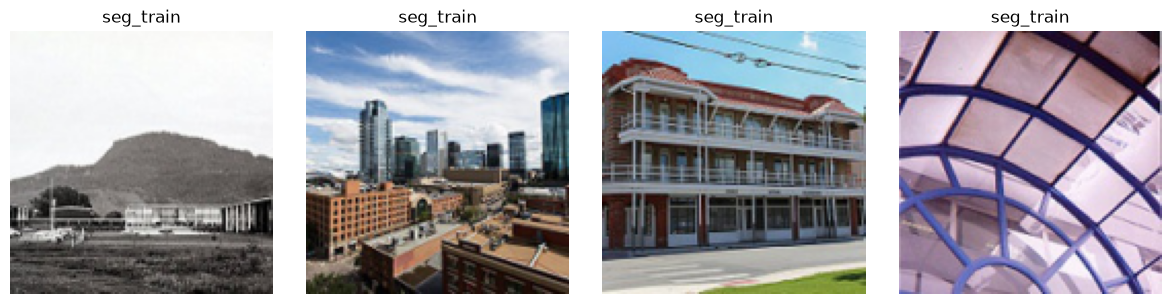

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    imagen, etiqueta = dataset[i]
    
    # Convertimos de Tensor (C,H,W) a formato Matplotlib (H,W,C)
    imagen = imagen.permute(1, 2, 0)

    axes[i].imshow(imagen)
    axes[i].set_title(dataset.classes[etiqueta])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
batch_size = 4

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [11]:
imagenes, etiquetas = next(iter(dataloader))

print("Dimensiones del lote:", imagenes.shape)
print("Etiquetas:", etiquetas)

Dimensiones del lote: torch.Size([4, 3, 128, 128])
Etiquetas: tensor([0, 0, 0, 0])


In [13]:
transform_train = transforms.Compose([
    transforms.Resize((160, 160)),
    
    # 1. Recorte aleatorio
    transforms.RandomCrop(150, padding=10),
    
    # 2. Rotación aleatoria
    transforms.RandomRotation(20),
    
    # 3. Flip horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 4. Cambios aleatorios de brillo
    transforms.ColorJitter(brightness=0.3),
    
    # 5. Escala de grises parcial
    transforms.RandomGrayscale(p=0.2),
    
    transforms.ToTensor()
])

In [15]:
transform_test = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

In [19]:
train_dataset = datasets.ImageFolder(
    root=ruta_train,
    transform=transform_train
)

test_dataset = datasets.ImageFolder(
    root=ruta_test,
    transform=transform_test
)

In [20]:
train_dataset = datasets.ImageFolder(
    root=ruta_train,
    transform=transform_train
)

test_dataset = datasets.ImageFolder(
    root=ruta_test,
    transform=transform_test
)

In [21]:
batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [22]:
batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

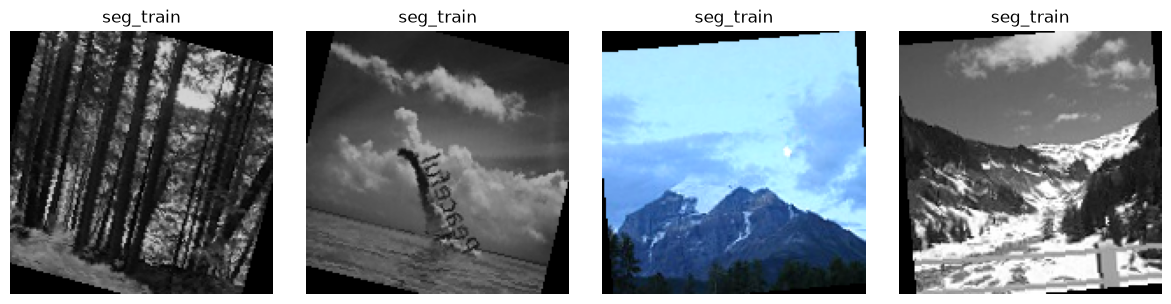

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    imagen = imagenes[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(imagen)
    axes[i].set_title(train_dataset.classes[etiquetas[i]])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [26]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        
        self.relu = nn.ReLU()
        
        self.fc1 = nn.Linear(
            64 * 37 * 37,
            128
        )
        
        self.fc2 = nn.Linear(
            128,
            num_classes
        )
        
    def forward(self, x):
        
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = torch.flatten(x, 1)
        
        x = self.relu(self.fc1(x))
        
        x = self.fc2(x)
        
        return x

In [28]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

num_classes = len(train_dataset.classes)

model = CNN(num_classes=num_classes)

model = model.to(device)

print(model)

Dispositivo utilizado: cpu
CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=87616, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [32]:
import torch.optim as optim

# Define your model first
# model = YourModel()

# Initialize the optimizer HERE, before the training loop or step
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Now this line will work
optimizer.zero_grad()   

criterion = torch.nn.CrossEntropyLoss()   


In [33]:
num_epochs = 30

for epoch in range(num_epochs):
    
    model.train()
    
    running_loss = 0.0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        # Limpiar gradientes
        optimizer.zero_grad()
        
        # Predicción
        outputs = model(images)
        
        # Calcular pérdida
        loss = criterion(outputs, labels)
        
        # Backpropagation
        loss.backward()
        
        # Actualizar pesos
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    
    print(
        f"Época [{epoch+1}/{num_epochs}] "
        f"- Pérdida: {epoch_loss:.4f}"
    )

KeyboardInterrupt: 

In [34]:
print("Imágenes de entrenamiento:", len(train_dataset))
print("Lotes por época:", len(train_loader))
print("Dispositivo:", device)

print(torch.cuda.is_available())

Imágenes de entrenamiento: 14034
Lotes por época: 3509
Dispositivo: cpu
False


In [35]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Precisión final del modelo: {accuracy:.2f}%")

Precisión final del modelo: 100.00%


In [ ]:
images, labels = next(iter(test_loader))

images_gpu = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images_gpu)
    _, predictions = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    
    imagen = images[i].permute(1, 2, 0).numpy()
    
    real = test_dataset.classes[labels[i]]
    pred = test_dataset.classes[predictions[i]]
    
    axes[i].imshow(imagen)
    axes[i].set_title(
        f"Real: {real}\nPred: {pred}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "modelo_cnn.pth")

print("Modelo guardado correctamente.")